# 00 — Artificial Neural Networks: the complete visual roadmap

> **Purpose:** build a mental model before touching implementation details. By the end of this notebook you should know exactly where **data, forward propagation, loss, backpropagation, optimization, representation learning, inference, and business policy** fit.

## What you should learn

- an ANN is a composition of simple differentiable transformations;
- **forward propagation** computes values using the current parameters;
- **loss** converts prediction quality into a scalar objective;
- **backpropagation** computes how sensitive that loss is to every parameter;
- an optimizer changes parameters, which changes the geometry of the hidden representation;
- the model produces a score; **business policy** decides what to do with that score.


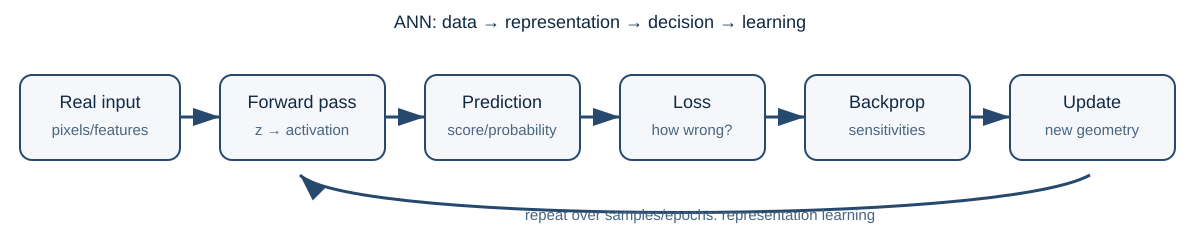

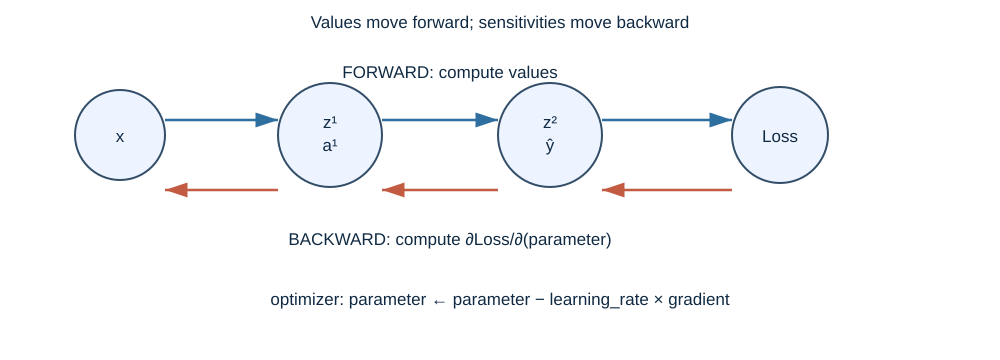

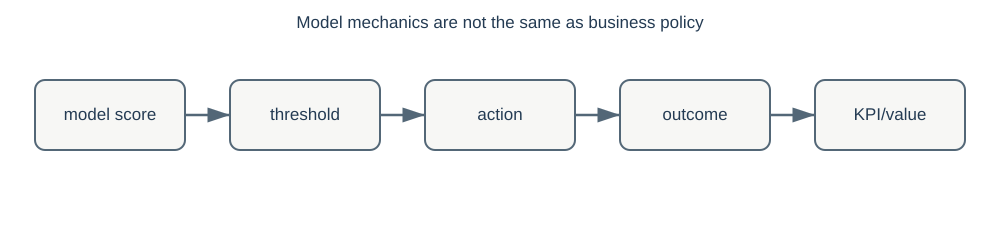

In [1]:
from pathlib import Path
from IPython.display import SVG, display
for name in ['ann_learning_map.svg','forward_backward.svg','business_loop.svg']:
    display(SVG(filename=str(Path('visual_learning')/name)))


## The one equation that organizes the entire course

For a dense layer:

$$
\mathbf z^{(l)} = \mathbf a^{(l-1)}W^{(l)} + \mathbf b^{(l)},
\qquad
\mathbf a^{(l)} = \phi(\mathbf z^{(l)})
$$

The output is compared with the target using a loss $\mathcal L$. Training asks:

$$
\frac{\partial \mathcal L}{\partial W^{(l)}}\;?\qquad
\frac{\partial \mathcal L}{\partial b^{(l)}}\;?
$$

Those derivatives are not abstract decoration. They answer a causal question:

> **If this parameter moves a tiny amount, how will the error move?**


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)

stages = pd.DataFrame({
    'stage':['raw data','forward pass','hidden representation','prediction','loss','backpropagation','optimizer','business policy'],
    'artifact':['x','z and a','coordinates/features','y_hat','L','gradients','new W,b','action'],
    'question':['what enters?','what is computed?','what did the network represent?','what does it believe?','how wrong?','what caused the error?','what changes next?','what should we do?']
})
stages


,stage,artifact,question
0,raw data,x,what enters?
1,forward pass,z and a,what is computed?
2,hidden representation,coordinates/features,what did the network represent?
3,prediction,y_hat,what does it believe?
4,loss,L,how wrong?
5,backpropagation,gradients,what caused the error?
6,optimizer,"new W,b",what changes next?
7,business policy,action,what should we do?


## Technical view vs business view

A technically excellent model can still be commercially poor if the action policy is wrong. Conversely, changing the threshold can change operational cost **without retraining the neural network**.

That distinction will matter in Notebook 11.

## Learning contract for every notebook

Each notebook follows the same sequence:

1. **intuition** — what problem are we solving?
2. **real data** — where do the numbers actually come from?
3. **manual arithmetic** — calculate a small case by hand/code line-by-line;
4. **vectorized implementation** — connect the arithmetic to production-style matrix code;
5. **visualization** — turn values/gradients/representations into geometry;
6. **what affects what** — perturb inputs/weights/hyperparameters and observe consequences;
7. **inference / insight** — explain what the result means;
8. **business / production connection** — connect mechanics to operational decisions.
